In [7]:
import pandas as pd
import requests
from io import StringIO

url = "https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M,T2MDEW,PRECTOTCORR,WS10M,PS&community=AG&longitude=76.9558&latitude=11.0168&start=20100101&end=20251231&format=CSV"

response = requests.get(url)

print("Status code:", response.status_code)

print(response.text[:1000])

Status code: 200
-BEGIN HEADER-
NASA/POWER Source Native Resolution Daily Data 
Dates (month/day/year): 01/01/2010 through 12/31/2025 in LST
Location: latitude  11.0168   longitude 76.9558 
elevation from MERRA-2: Average for 0.5 x 0.625 degree lat/lon region = 540.94 meters
The value for missing source data that cannot be computed or is outside of the sources availability range: -999 
parameter(s): 
T2M             MERRA-2 Temperature at 2 Meters (C) 
T2MDEW          MERRA-2 Dew/Frost Point at 2 Meters (C) 
PRECTOTCORR     MERRA-2 Precipitation Corrected (mm/day) 
WS10M           MERRA-2 Wind Speed at 10 Meters (m/s) 
PS              MERRA-2 Surface Pressure (kPa) 
-END HEADER-
YEAR,DOY,T2M,T2MDEW,PRECTOTCORR,WS10M,PS
2010,1,23.43,17.97,0.0,3.28,95.1
2010,2,22.71,16.1,0.0,3.39,95.24
2010,3,21.14,15.88,0.0,2.92,95.28
2010,4,21.93,14.5,0.0,2.39,95.12
2010,5,22.06,14.31,0.0,1.57,94.96
2010,6,21.89,15.33,0.0,2.83,94.99
2010,7,22.78,16.85,0.0,2.32,95.06
2010,8,23.21,16.81,0.0,2.11,95.0


In [8]:
import pandas as pd
import requests
from io import StringIO

url = "https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M,T2MDEW,PRECTOTCORR,WS10M,PS&community=AG&longitude=76.9558&latitude=11.0168&start=20100101&end=20251231&format=CSV"

response = requests.get(url)

print("Status code:", response.status_code)

# Find the actual CSV header
text = response.text
csv_data = text[text.index("YEAR,DOY"):]

df = pd.read_csv(StringIO(csv_data))

df.head()

Status code: 200


,YEAR,DOY,T2M,T2MDEW,PRECTOTCORR,WS10M,PS
0,2010,1,23.43,17.97,0.0,3.28,95.10
1,2010,2,22.71,16.10,0.0,3.39,95.24
2,2010,3,21.14,15.88,0.0,2.92,95.28
3,2010,4,21.93,14.50,0.0,2.39,95.12
4,2010,5,22.06,14.31,0.0,1.57,94.96


In [9]:
df["DATE"] = pd.to_datetime(
    df["YEAR"].astype(str) + df["DOY"].astype(str),
    format="%Y%j"
)

df.head()

,YEAR,DOY,T2M,T2MDEW,PRECTOTCORR,WS10M,PS,DATE
0,2010,1,23.43,17.97,0.0,3.28,95.10,2010-01-01
1,2010,2,22.71,16.10,0.0,3.39,95.24,2010-01-02
2,2010,3,21.14,15.88,0.0,2.92,95.28,2010-01-03
3,2010,4,21.93,14.50,0.0,2.39,95.12,2010-01-04
4,2010,5,22.06,14.31,0.0,1.57,94.96,2010-01-05


In [10]:
df = df[["DATE", "T2M", "T2MDEW", "PRECTOTCORR", "WS10M", "PS"]]

df.head()

,DATE,T2M,T2MDEW,PRECTOTCORR,WS10M,PS
0,2010-01-01,23.43,17.97,0.0,3.28,95.10
1,2010-01-02,22.71,16.10,0.0,3.39,95.24
2,2010-01-03,21.14,15.88,0.0,2.92,95.28
3,2010-01-04,21.93,14.50,0.0,2.39,95.12
4,2010-01-05,22.06,14.31,0.0,1.57,94.96


In [11]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Shape: (5844, 6)

Columns:
Index(['DATE', 'T2M', 'T2MDEW', 'PRECTOTCORR', 'WS10M', 'PS'], dtype='object')

Missing values:
DATE           0
T2M            0
T2MDEW         0
PRECTOTCORR    0
WS10M          0
PS             0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE         5844 non-null   datetime64[ns]
 1   T2M          5844 non-null   float64       
 2   T2MDEW       5844 non-null   float64       
 3   PRECTOTCORR  5844 non-null   float64       
 4   WS10M        5844 non-null   float64       
 5   PS           5844 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 274.1 KB


In [12]:
print((df == -999).sum())

DATE           0
T2M            0
T2MDEW         0
PRECTOTCORR    0
WS10M          0
PS             0
dtype: int64


In [13]:
df = df.replace(-999, pd.NA)

In [14]:
df.to_csv("coimbatore_weather_2010_2025.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [15]:
from google.colab import files

files.download("coimbatore_weather_2010_2025.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
print(df.shape)
print(df.isnull().sum())
df.describe()

(5844, 6)
DATE           0
T2M            0
T2MDEW         0
PRECTOTCORR    0
WS10M          0
PS             0
dtype: int64


,DATE,T2M,T2MDEW,PRECTOTCORR,WS10M,PS
count,5844,5844.000000,5844.000000,5844.000000,5844.000000,5844.000000
mean,2017-12-31 12:00:00,24.687630,19.128753,3.281395,3.186877,94.933335
min,2010-01-01 00:00:00,18.290000,2.760000,0.000000,0.540000,94.210000
25%,2013-12-31 18:00:00,23.290000,17.670000,0.020000,2.150000,94.780000
50%,2017-12-31 12:00:00,24.220000,20.420000,1.130000,3.000000,94.920000
75%,2021-12-31 06:00:00,25.820000,21.290000,4.522500,4.000000,95.080000
max,2025-12-31 00:00:00,32.210000,24.280000,57.950000,8.830000,95.580000
std,NaN,2.226715,3.177654,5.135468,1.352398,0.204275


In [17]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.dtypes)

        DATE    T2M  T2MDEW  PRECTOTCORR  WS10M     PS
0 2010-01-01  23.43   17.97          0.0   3.28  95.10
1 2010-01-02  22.71   16.10          0.0   3.39  95.24
2 2010-01-03  21.14   15.88          0.0   2.92  95.28
3 2010-01-04  21.93   14.50          0.0   2.39  95.12
4 2010-01-05  22.06   14.31          0.0   1.57  94.96
           DATE    T2M  T2MDEW  PRECTOTCORR  WS10M     PS
5839 2025-12-27  21.74   15.91         0.00   2.81  95.12
5840 2025-12-28  21.86   16.36         0.00   2.61  95.19
5841 2025-12-29  22.64   17.76         0.00   2.50  95.15
5842 2025-12-30  23.52   18.14         0.00   1.46  95.13
5843 2025-12-31  23.82   18.34         1.13   1.63  95.00
(5844, 6)
DATE           datetime64[ns]
T2M                   float64
T2MDEW                float64
PRECTOTCORR           float64
WS10M                 float64
PS                    float64
dtype: object


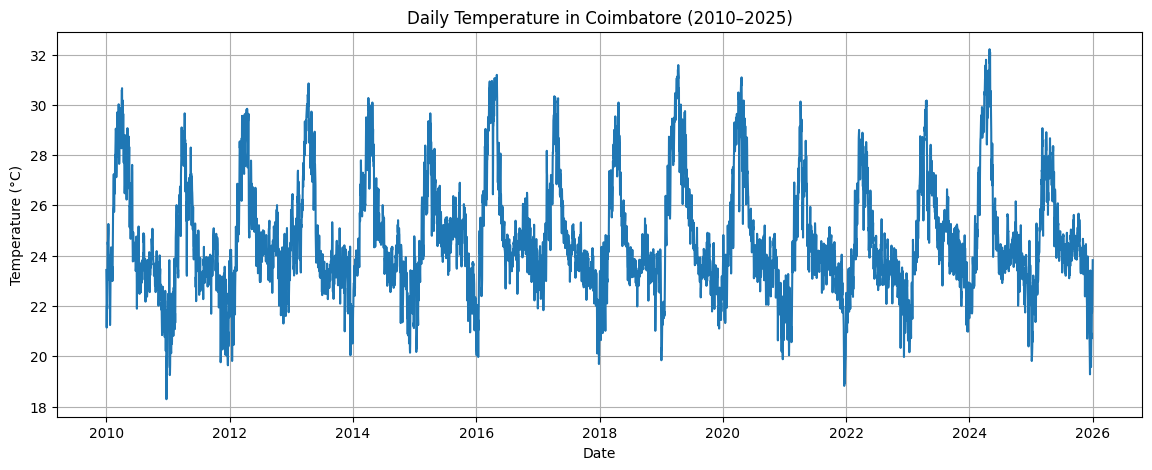

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(df["DATE"], df["T2M"])

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Daily Temperature in Coimbatore (2010–2025)")
plt.grid(True)

plt.show()

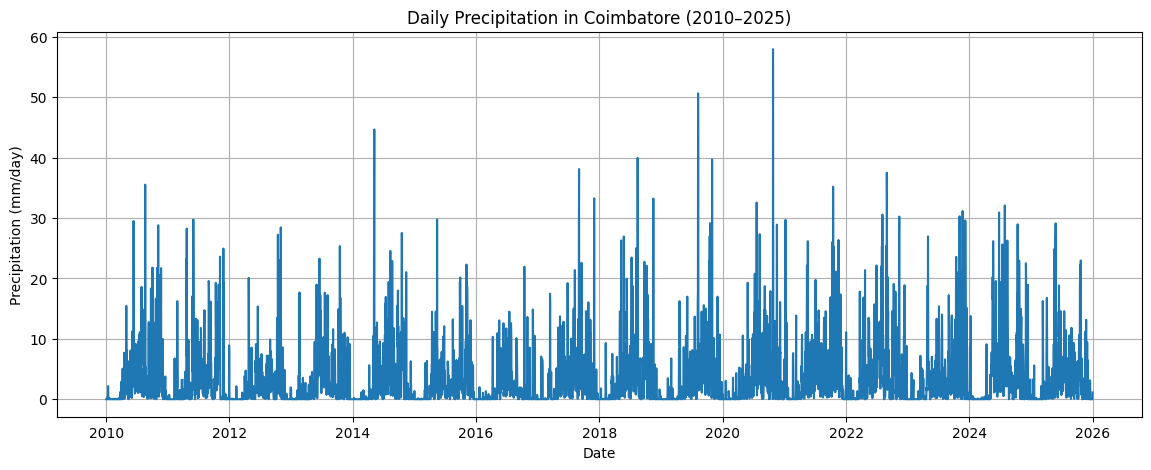

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(df["DATE"], df["PRECTOTCORR"])

plt.xlabel("Date")
plt.ylabel("Precipitation (mm/day)")
plt.title("Daily Precipitation in Coimbatore (2010–2025)")
plt.grid(True)

plt.show()

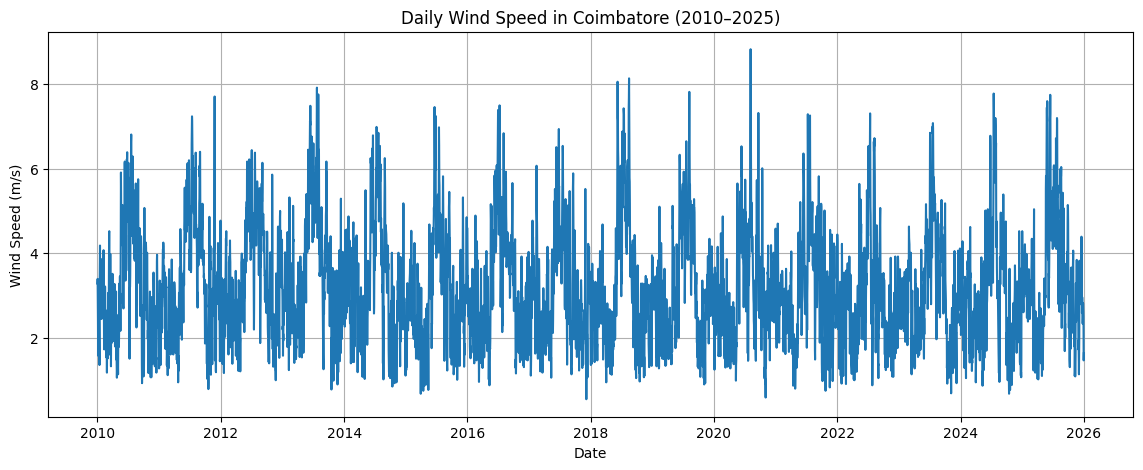

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(df["DATE"], df["WS10M"])

plt.xlabel("Date")
plt.ylabel("Wind Speed (m/s)")
plt.title("Daily Wind Speed in Coimbatore (2010–2025)")
plt.grid(True)

plt.show()

In [21]:
df["MONTH"] = df["DATE"].dt.month

In [22]:
monthly = df.groupby("MONTH").agg({
    "T2M": "mean",
    "PRECTOTCORR": "mean",
    "WS10M": "mean",
    "PS": "mean"
})

monthly

,T2M,PRECTOTCORR,WS10M,PS
MONTH,,,,
1,22.659173,0.498246,2.818548,95.179879
2,24.830420,0.338872,2.874934,95.140265
3,27.654395,0.761774,2.449899,95.029657
4,28.570042,2.027208,2.144813,94.889167
5,26.603306,4.328085,3.074375,94.771835
6,24.722687,4.925958,4.609979,94.752500
7,23.932258,5.255887,4.929859,94.759476
8,23.932036,4.997218,4.224919,94.794052
9,24.027542,4.320063,3.506771,94.840458


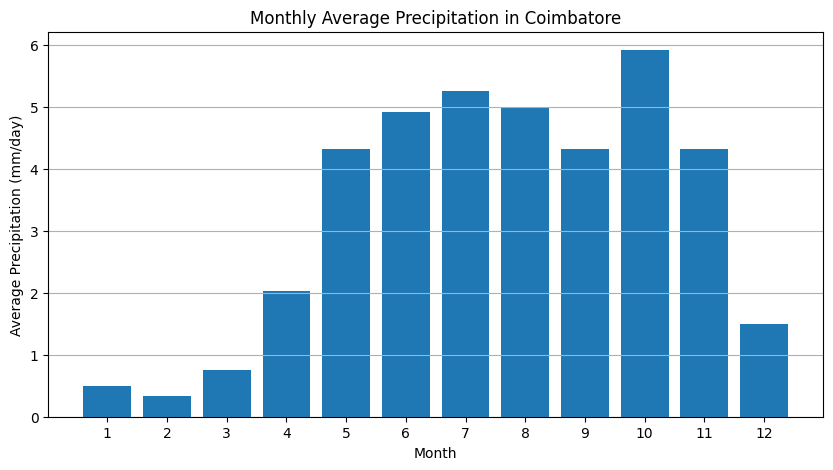

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly.index,
    monthly["PRECTOTCORR"]
)

plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm/day)")
plt.title("Monthly Average Precipitation in Coimbatore")
plt.xticks(range(1, 13))
plt.grid(axis="y")

plt.show()

In [24]:
# Find the months with highest and lowest average rainfall

highest_rainfall_month = monthly["PRECTOTCORR"].idxmax()
lowest_rainfall_month = monthly["PRECTOTCORR"].idxmin()

print("Month with highest average rainfall:", highest_rainfall_month)
print("Highest average rainfall:",
      monthly["PRECTOTCORR"].max(), "mm/day")

print("\nMonth with lowest average rainfall:", lowest_rainfall_month)
print("Lowest average rainfall:",
      monthly["PRECTOTCORR"].min(), "mm/day")

Month with highest average rainfall: 10
Highest average rainfall: 5.924072580645162 mm/day

Month with lowest average rainfall: 2
Lowest average rainfall: 0.33887168141592916 mm/day


In [25]:
monsoon = monthly.loc[6:9]

print("Southwest Monsoon Statistics:")
print(monsoon)

print("\nAverage monsoon precipitation:",
      monsoon["PRECTOTCORR"].mean(), "mm/day")

Southwest Monsoon Statistics:
             T2M  PRECTOTCORR     WS10M         PS
MONTH                                             
6      24.722687     4.925958  4.609979  94.752500
7      23.932258     5.255887  4.929859  94.759476
8      23.932036     4.997218  4.224919  94.794052
9      24.027542     4.320063  3.506771  94.840458

Average monsoon precipitation: 4.874781418010752 mm/day


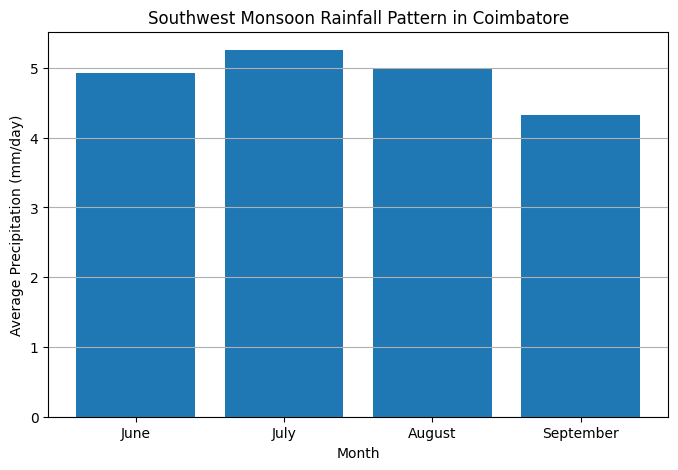

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    monsoon.index,
    monsoon["PRECTOTCORR"]
)

plt.xlabel("Month")
plt.ylabel("Average Precipitation (mm/day)")
plt.title("Southwest Monsoon Rainfall Pattern in Coimbatore")
plt.xticks([6, 7, 8, 9], ["June", "July", "August", "September"])
plt.grid(axis="y")

plt.show()

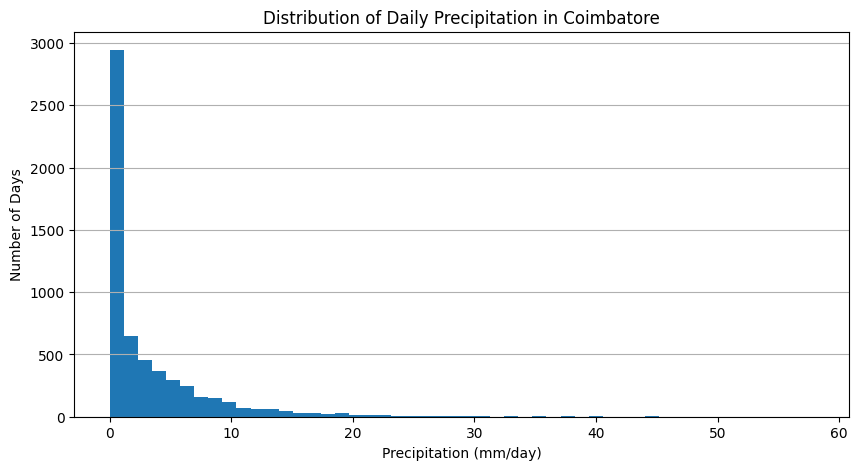

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(df["PRECTOTCORR"], bins=50)

plt.xlabel("Precipitation (mm/day)")
plt.ylabel("Number of Days")
plt.title("Distribution of Daily Precipitation in Coimbatore")
plt.grid(axis="y")

plt.show()

In [28]:
print(df["PRECTOTCORR"].describe())

count    5844.000000
mean        3.281395
std         5.135468
min         0.000000
25%         0.020000
50%         1.130000
75%         4.522500
max        57.950000
Name: PRECTOTCORR, dtype: float64


In [29]:
df["RAIN_EVENT"] = (df["PRECTOTCORR"] > 2.5).astype(int)

print(df["RAIN_EVENT"].value_counts())

RAIN_EVENT
0    3680
1    2164
Name: count, dtype: int64


In [30]:
print(
    df["RAIN_EVENT"]
    .value_counts(normalize=True)
    .mul(100)
)

RAIN_EVENT
0    62.970568
1    37.029432
Name: proportion, dtype: float64


In [31]:
import matplotlib.pyplot as plt
import pandas as pd

correlation = df[
    ["T2M", "T2MDEW", "PRECTOTCORR", "WS10M", "PS"]
].corr()

print(correlation)

                  T2M    T2MDEW  PRECTOTCORR     WS10M        PS
T2M          1.000000 -0.029090    -0.134822 -0.240566 -0.181745
T2MDEW      -0.029090  1.000000     0.413509  0.178982 -0.554948
PRECTOTCORR -0.134822  0.413509     1.000000  0.159486 -0.334284
WS10M       -0.240566  0.178982     0.159486  1.000000 -0.342754
PS          -0.181745 -0.554948    -0.334284 -0.342754  1.000000


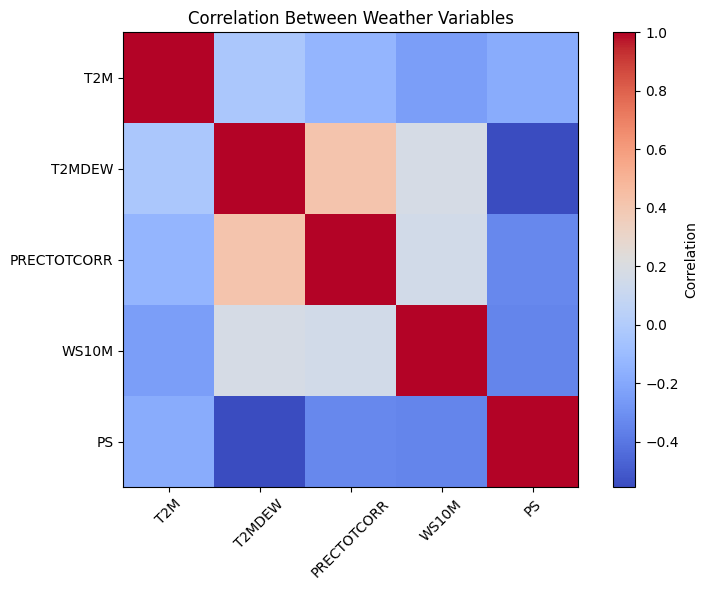

In [32]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Between Weather Variables")

plt.tight_layout()
plt.show()

In [33]:
rain_corr = correlation["PRECTOTCORR"].sort_values(ascending=False)

print("Correlation with precipitation:")
print(rain_corr)

Correlation with precipitation:
PRECTOTCORR    1.000000
T2MDEW         0.413509
WS10M          0.159486
T2M           -0.134822
PS            -0.334284
Name: PRECTOTCORR, dtype: float64


In [34]:
df["MONTH"] = df["DATE"].dt.month
df["DAY_OF_YEAR"] = df["DATE"].dt.dayofyear

df["RAIN_LAG_1"] = df["PRECTOTCORR"].shift(1)
df["RAIN_LAG_3"] = df["PRECTOTCORR"].shift(3)
df["RAIN_LAG_7"] = df["PRECTOTCORR"].shift(7)

df["TEMP_LAG_1"] = df["T2M"].shift(1)

df["RAIN_ROLLING_7"] = (
    df["PRECTOTCORR"]
    .rolling(7)
    .mean()
)

df["TEMP_ROLLING_7"] = (
    df["T2M"]
    .rolling(7)
    .mean()
)

In [35]:
print(df.head(10))

        DATE    T2M  T2MDEW  PRECTOTCORR  WS10M     PS  MONTH  RAIN_EVENT  \
0 2010-01-01  23.43   17.97         0.00   3.28  95.10      1           0   
1 2010-01-02  22.71   16.10         0.00   3.39  95.24      1           0   
2 2010-01-03  21.14   15.88         0.00   2.92  95.28      1           0   
3 2010-01-04  21.93   14.50         0.00   2.39  95.12      1           0   
4 2010-01-05  22.06   14.31         0.00   1.57  94.96      1           0   
5 2010-01-06  21.89   15.33         0.00   2.83  94.99      1           0   
6 2010-01-07  22.78   16.85         0.00   2.32  95.06      1           0   
7 2010-01-08  23.21   16.81         0.00   2.11  95.09      1           0   
8 2010-01-09  24.54   19.59         0.28   2.95  95.04      1           0   
9 2010-01-10  24.44   19.07         0.41   2.59  95.13      1           0   

   DAY_OF_YEAR  RAIN_LAG_1  RAIN_LAG_3  RAIN_LAG_7  TEMP_LAG_1  \
0            1         NaN         NaN         NaN         NaN   
1            2      

In [36]:
df = df.dropna().reset_index(drop=True)

print("New dataset shape:", df.shape)

New dataset shape: (5837, 15)


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features used for rainfall prediction
features = [
    "T2M",
    "T2MDEW",
    "WS10M",
    "PS",
    "MONTH",
    "DAY_OF_YEAR",
    "RAIN_LAG_1",
    "RAIN_LAG_3",
    "RAIN_LAG_7",
    "TEMP_LAG_1",
    "RAIN_ROLLING_7",
    "TEMP_ROLLING_7"
]

X = df[features]
y = df["PRECTOTCORR"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5837, 12)
y shape: (5837,)


In [38]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4669
Testing samples: 1168


In [39]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [41]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 2.082226965042433
RMSE: 3.519944640478353
R²  : 0.5503459785969856


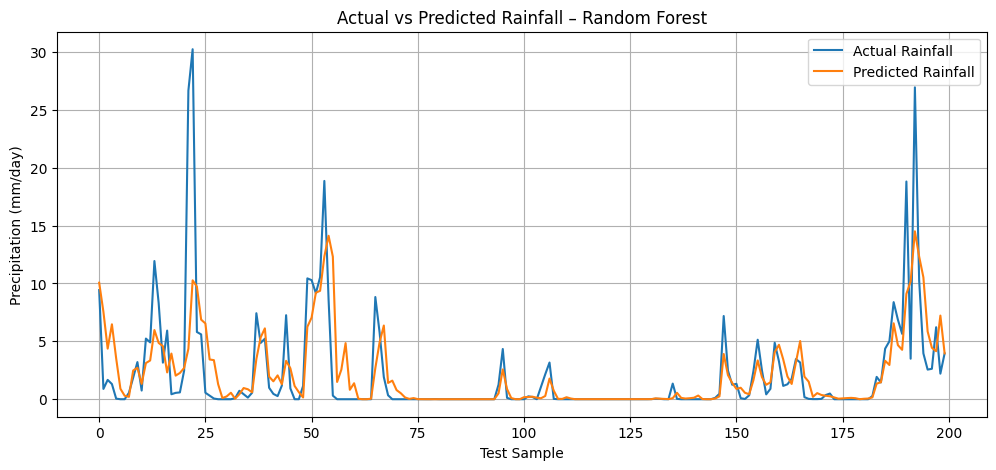

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:200],
    label="Actual Rainfall"
)

plt.plot(
    y_pred_rf[:200],
    label="Predicted Rainfall"
)

plt.xlabel("Test Sample")
plt.ylabel("Precipitation (mm/day)")
plt.title("Actual vs Predicted Rainfall – Random Forest")
plt.legend()
plt.grid()

plt.show()

In [43]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Results
----------------
MAE : 2.030582691347079
RMSE: 3.4628257398993623
R²  : 0.5648208400650814


In [44]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [mae_rf, mae_xgb],
    "RMSE": [rmse_rf, rmse_xgb],
    "R2": [r2_rf, r2_xgb]
})

print(comparison)

           Model       MAE      RMSE        R2
0  Random Forest  2.082227  3.519945  0.550346
1        XGBoost  2.030583  3.462826  0.564821


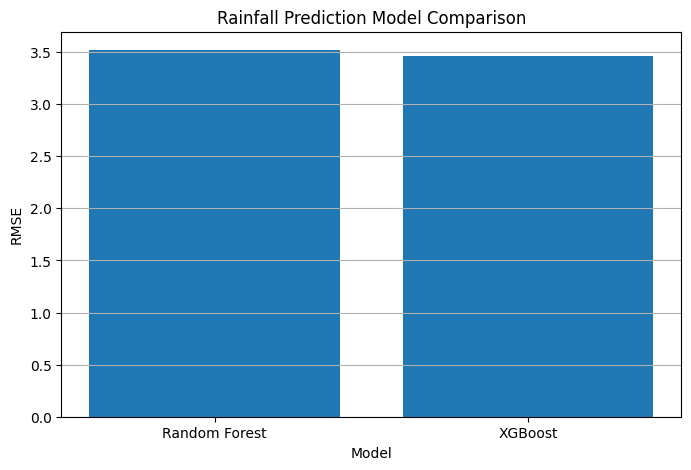

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Rainfall Prediction Model Comparison")
plt.grid(axis="y")

plt.show()

In [46]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
10  RAIN_ROLLING_7    0.286151
6       RAIN_LAG_1    0.125598
7       RAIN_LAG_3    0.080711
2            WS10M    0.068235
1           T2MDEW    0.066697
8       RAIN_LAG_7    0.060150
11  TEMP_ROLLING_7    0.056025
9       TEMP_LAG_1    0.055301
5      DAY_OF_YEAR    0.050918
4            MONTH    0.050619
3               PS    0.049806
0              T2M    0.049790


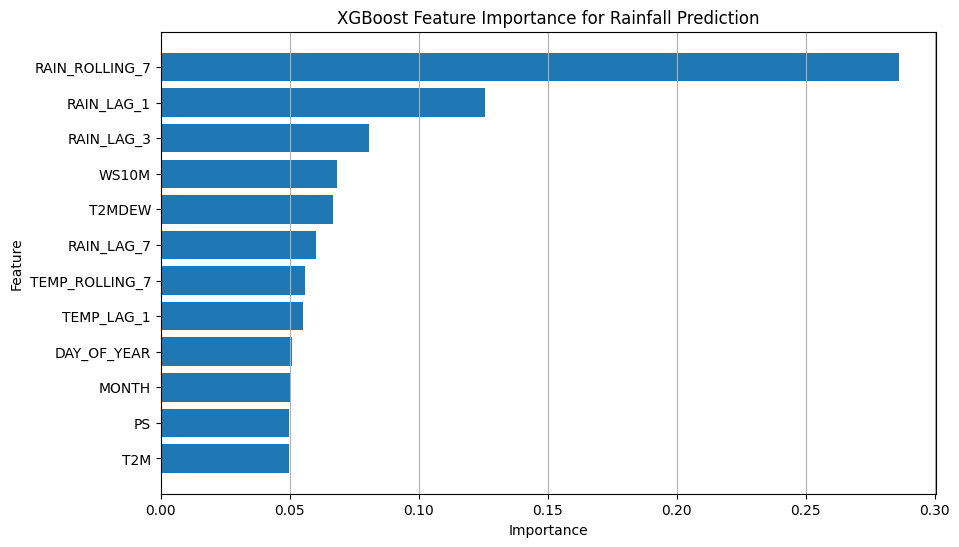

In [47]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance for Rainfall Prediction")
plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

In [48]:
import joblib

joblib.dump(xgb_model, "xgboost_rainfall_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [49]:
latest_data = X.iloc[[-1]]

predicted_rainfall = xgb_model.predict(latest_data)[0]

print("Predicted rainfall:", round(predicted_rainfall, 2), "mm/day")

Predicted rainfall: 0.37 mm/day


In [50]:
actual_rainfall = y.iloc[-1]

print("Actual rainfall:", actual_rainfall, "mm/day")
print("Predicted rainfall:", round(predicted_rainfall, 2), "mm/day")

Actual rainfall: 1.13 mm/day
Predicted rainfall: 0.37 mm/day


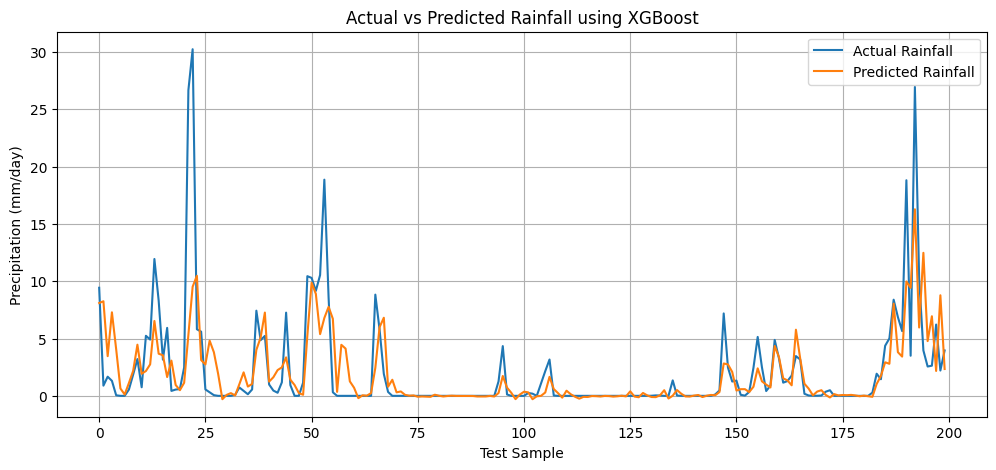

In [51]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:200],
    label="Actual Rainfall"
)

plt.plot(
    y_pred_xgb[:200],
    label="Predicted Rainfall"
)

plt.xlabel("Test Sample")
plt.ylabel("Precipitation (mm/day)")
plt.title("Actual vs Predicted Rainfall using XGBoost")
plt.legend()
plt.grid()

plt.show()

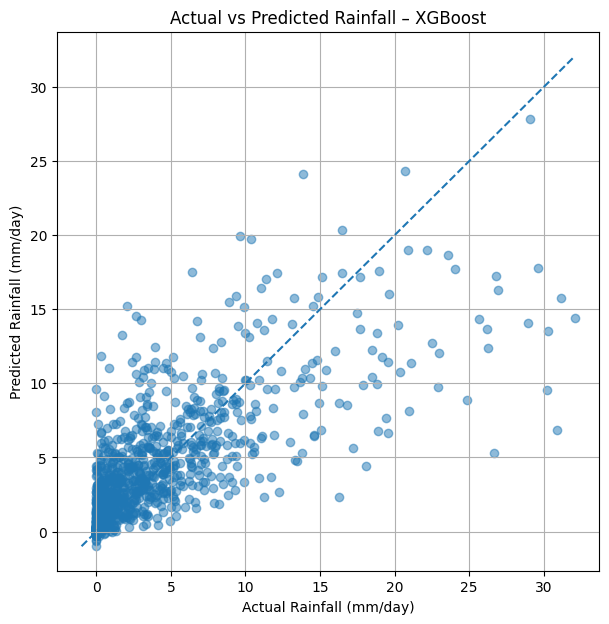

In [52]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.5
)

plt.xlabel("Actual Rainfall (mm/day)")
plt.ylabel("Predicted Rainfall (mm/day)")
plt.title("Actual vs Predicted Rainfall – XGBoost")

# Ideal prediction line
min_value = min(y_test.min(), y_pred_xgb.min())
max_value = max(y_test.max(), y_pred_xgb.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.grid()
plt.show()

In [ ]:
!pip install shap -q

In [53]:
import shap

In [54]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1168, 12)


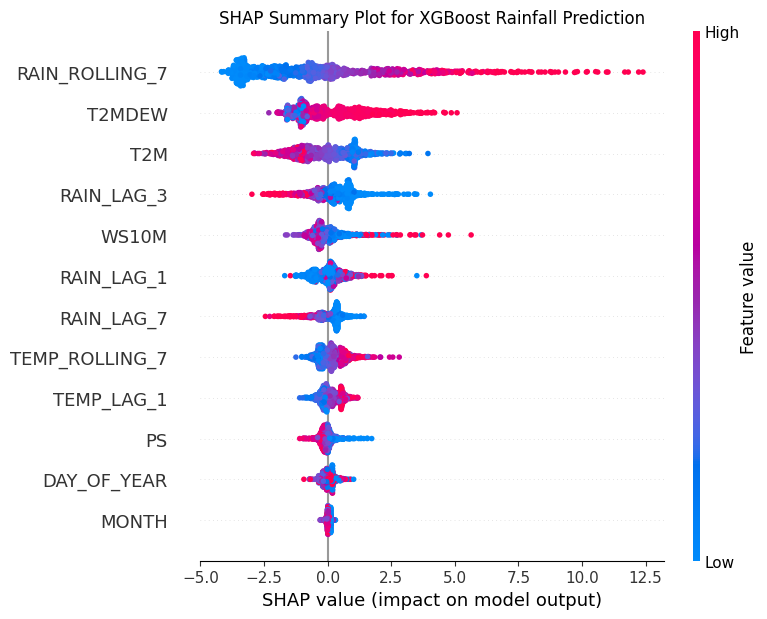

In [55]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot for XGBoost Rainfall Prediction")
plt.tight_layout()
plt.show()

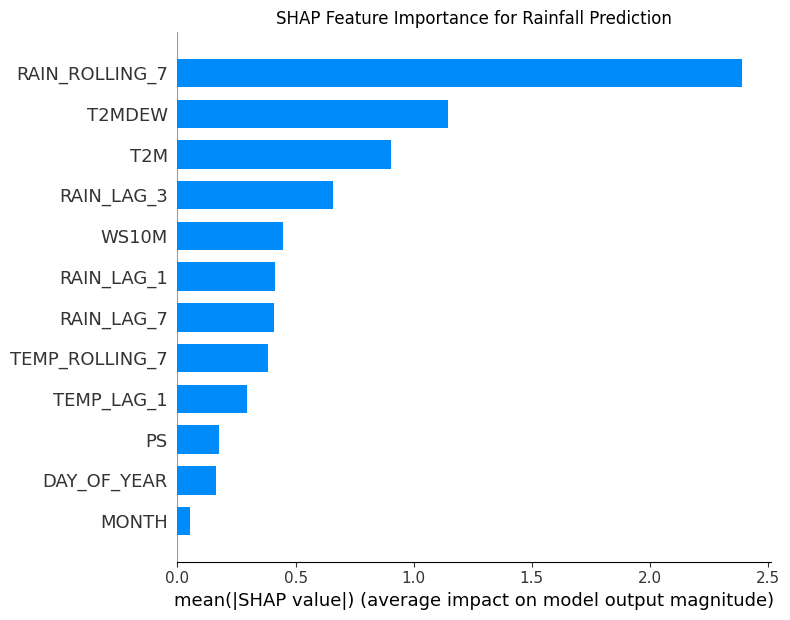

In [56]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance for Rainfall Prediction")
plt.tight_layout()
plt.show()

In [58]:
print(X_train.columns.tolist())

['T2M', 'T2MDEW', 'WS10M', 'PS', 'MONTH', 'DAY_OF_YEAR', 'RAIN_LAG_1', 'RAIN_LAG_3', 'RAIN_LAG_7', 'TEMP_LAG_1', 'RAIN_ROLLING_7', 'TEMP_ROLLING_7']


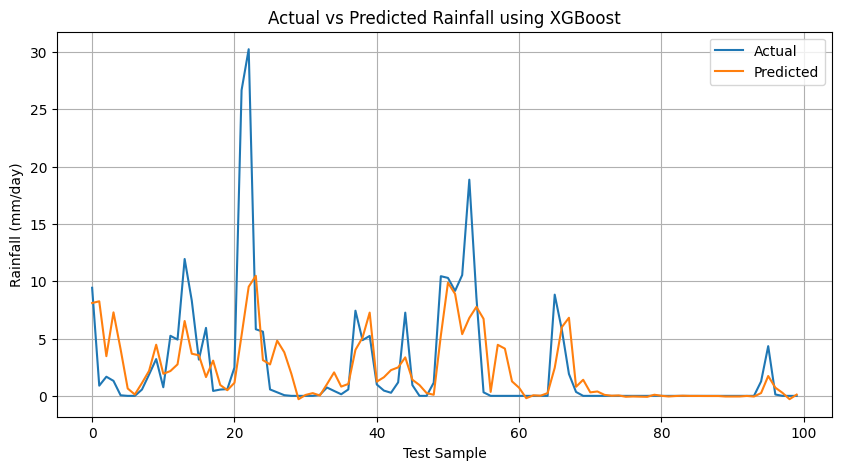

In [61]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred_xgb[:100], label="Predicted")

plt.xlabel("Test Sample")
plt.ylabel("Rainfall (mm/day)")
plt.title("Actual vs Predicted Rainfall using XGBoost")
plt.legend()
plt.grid()

plt.show()

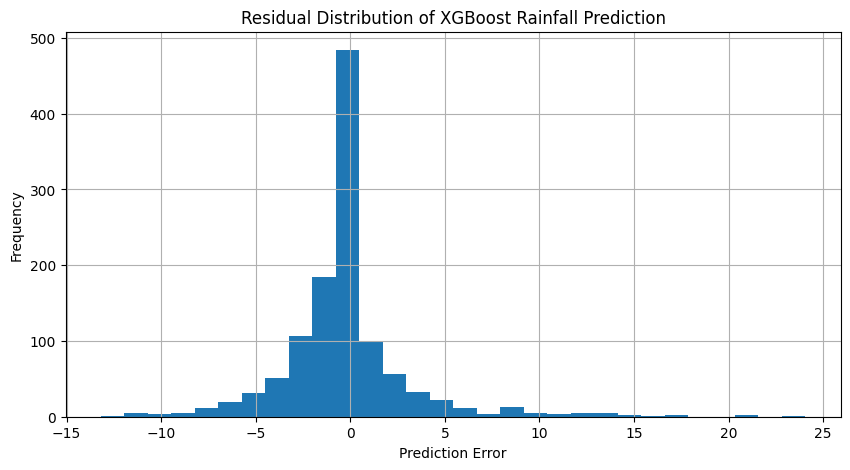

In [64]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(10,5))

plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution of XGBoost Rainfall Prediction")

plt.grid()
plt.show()

In [65]:
print("Mean Residual:", residuals.mean())
print("Maximum Error:", residuals.abs().max())

Mean Residual: -0.2327458866673668
Maximum Error: 24.062253398895265


In [66]:
joblib.dump(xgb_model, "xgboost_rainfall_model.pkl")

['xgboost_rainfall_model.pkl']

In [67]:
import json

features = X_train.columns.tolist()

with open("features.json", "w") as f:
    json.dump(features, f)

print(features)

['T2M', 'T2MDEW', 'WS10M', 'PS', 'MONTH', 'DAY_OF_YEAR', 'RAIN_LAG_1', 'RAIN_LAG_3', 'RAIN_LAG_7', 'TEMP_LAG_1', 'RAIN_ROLLING_7', 'TEMP_ROLLING_7']
